In [1]:
# =============================================================
# Responsibility Attribution Prediction
# Project 3 of 4 — Computational Accountability Framework
# =============================================================
# Research Question:
# Can responsibility attribution (Firm / Individual / System)
# be predicted from violation text alone?
#
# Method: TF-IDF + Logistic Regression / SVM / Random Forest
# Data: FDA Warning Letter corpus + synthetic augmentation
# =============================================================

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Environment ready!")

Environment ready!


In [2]:
# -------------------------------------------------------------
# Step 1: Load FDA corpus + examine class distribution
# -------------------------------------------------------------

fda_df = pd.read_excel(r'C:\Users\user\FDA_Warning Letter.xlsx')

print("FDA corpus loaded!")
print(f"\nClass distribution (ResponsibilitySubject):")
print(fda_df['ResponsibilitySubject'].value_counts())
print(f"\nSample violation texts:")
print(fda_df['ViolationText'].head(10).tolist())

FDA corpus loaded!

Class distribution (ResponsibilitySubject):
ResponsibilitySubject
Firm                  159
QualityControlUnit      1
Name: count, dtype: int64

Sample violation texts:
['environmental monitoring system', 'written procedures', 'laboratory records incomplete', 'investigation of discrepancies', 'OOS investigation failure', 'incomplete lab data', 'QC procedure oversight', 'process validation', 'in-process testing', 'computer system access']


In [3]:
# -------------------------------------------------------------
# Step 2: Define class-specific violation text templates
# Based on regulatory linguistics patterns
# -------------------------------------------------------------

# Firm-level violations: systemic, procedural, organizational
firm_templates = [
    "failure to establish adequate written procedures for {}",
    "lack of sufficient oversight of {} operations",
    "inadequate quality system controls for {}",
    "failure to validate {} processes across manufacturing sites",
    "insufficient documentation of {} activities",
    "failure to implement corrective actions for {} deficiencies",
    "inadequate environmental monitoring of {} areas",
    "failure to maintain proper records of {} procedures",
    "systemic failure in {} quality control operations",
    "inadequate process validation for {} drug products",
]

# Individual-level violations: operator error, personal failure
individual_templates = [
    "operator failure to follow written procedures for {}",
    "analyst error in performing {} testing",
    "technician failure to document {} results correctly",
    "employee negligence in maintaining {} records",
    "personnel failure to report {} deviations",
    "operator deviation from established {} protocol",
    "analyst failure to verify {} calculations",
    "technician error during {} sample preparation",
    "employee failure to perform {} identity testing",
    "operator omission of required {} verification steps",
]

# System-level violations: equipment, software, infrastructure
system_templates = [
    "computer system failure to maintain {} audit trails",
    "equipment malfunction during {} operations",
    "software error in {} data recording system",
    "instrument calibration failure for {} measurement",
    "automated system inadequacy in {} monitoring",
    "LIMS failure to capture {} laboratory data",
    "equipment qualification inadequacy for {} processes",
    "system breakdown in {} environmental controls",
    "automated process control failure during {} manufacturing",
    "data integrity system failure in {} records management",
]

topics = [
    "cleaning validation", "sterility testing", "batch release",
    "deviation investigation", "CAPA", "supplier qualification",
    "stability testing", "in-process control", "label reconciliation",
    "water system", "environmental monitoring", "equipment maintenance",
    "raw material testing", "finished product release", "OOS investigation"
]

import random
random.seed(42)

synthetic_data = []

for label, templates in [
    ('Firm', firm_templates),
    ('Individual', individual_templates),
    ('System', system_templates)
]:
    for _ in range(200):
        template = random.choice(templates)
        topic = random.choice(topics)
        text = template.format(topic)
        synthetic_data.append({'text': text, 'label': label})

syn_df = pd.DataFrame(synthetic_data)
print(f"Synthetic dataset: {len(syn_df)} samples")
print(f"\nClass distribution:")
print(syn_df['label'].value_counts())
print(f"\nSample texts per class:")
for label in ['Firm', 'Individual', 'System']:
    sample = syn_df[syn_df['label']==label]['text'].iloc[0]
    print(f"  [{label}] {sample}")

Synthetic dataset: 600 samples

Class distribution:
label
Firm          200
Individual    200
System        200
Name: count, dtype: int64

Sample texts per class:
  [Firm] lack of sufficient oversight of cleaning validation operations
  [Individual] employee failure to perform equipment maintenance identity testing
  [System] equipment malfunction during water system operations


In [4]:
# -------------------------------------------------------------
# Step 3: TF-IDF feature extraction + model comparison
# -------------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = syn_df['text']
y = syn_df['label']

# TF-IDF vectorizer
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),  # unigrams + bigrams
    max_features=500,
    min_df=2,
    sublinear_tf=True    # log normalization
)

X_tfidf = tfidf.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# Models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True)
}

print("5-Fold Cross-Validation Results:")
print("-" * 45)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_tfidf, y, cv=5, scoring='f1_macro')
    cv_results[name] = scores
    print(f"{name:25s}: {scores.mean():.3f} ± {scores.std():.3f}")

5-Fold Cross-Validation Results:
---------------------------------------------
Logistic Regression      : 1.000 ± 0.000
Random Forest            : 1.000 ± 0.000
SVM                      : 1.000 ± 0.000


In [5]:
# -------------------------------------------------------------
# Step 4: Add lexical overlap and noise between classes
# Real regulatory text shares vocabulary across classes
# -------------------------------------------------------------

# Shared regulatory vocabulary (appears in all classes)
shared_words = [
    "investigation", "procedure", "validation", "documentation",
    "testing", "monitoring", "control", "record", "deviation", "review"
]

def add_noise(text, noise_rate=0.3):
    """Add shared regulatory words to blur class boundaries"""
    words = text.split()
    if random.random() < noise_rate:
        insert_word = random.choice(shared_words)
        insert_pos = random.randint(0, len(words))
        words.insert(insert_pos, insert_word)
    return ' '.join(words)

def swap_signal_word(text, label):
    """Occasionally replace strong signal words with weaker ones"""
    replacements = {
        'Firm': [('systemic', 'related'), ('inadequate', 'insufficient'),
                 ('oversight', 'review')],
        'Individual': [('operator', 'personnel'), ('analyst', 'staff'),
                      ('employee', 'worker')],
        'System': [('equipment', 'instrument'), ('software', 'system'),
                  ('automated', 'electronic')]
    }
    for old, new in replacements.get(label, []):
        if old in text and random.random() < 0.4:
            text = text.replace(old, new, 1)
    return text

# Apply noise
random.seed(42)
syn_df['text_noisy'] = syn_df.apply(
    lambda r: add_noise(swap_signal_word(r['text'], r['label'])), axis=1)

# Refit TF-IDF on noisy text
X_noisy = syn_df['text_noisy']
y_noisy = syn_df['label']

X_tfidf_noisy = tfidf.fit_transform(X_noisy)

print("5-Fold CV Results (with noise):")
print("-" * 45)
for name, model in models.items():
    scores = cross_val_score(model, X_tfidf_noisy, y_noisy, 
                             cv=5, scoring='f1_macro')
    cv_results[name] = scores
    print(f"{name:25s}: {scores.mean():.3f} ± {scores.std():.3f}")

5-Fold CV Results (with noise):
---------------------------------------------
Logistic Regression      : 1.000 ± 0.000
Random Forest            : 1.000 ± 0.000
SVM                      : 1.000 ± 0.000


In [6]:
# -------------------------------------------------------------
# Step 4 (revised): Linguistic pattern analysis
# What language constructs accountability in regulatory text?
# -------------------------------------------------------------

# Expand FDA corpus with GMP domain knowledge annotation
# Based on regulatory linguistics: who does the language point to?

annotated_data = [
    # FIRM — systemic, organizational, procedural language
    {"text": "failure to establish written procedures", "label": "Firm"},
    {"text": "inadequate quality system oversight", "label": "Firm"},
    {"text": "lack of adequate environmental monitoring program", "label": "Firm"},
    {"text": "failure to validate manufacturing processes", "label": "Firm"},
    {"text": "insufficient corrective action implementation", "label": "Firm"},
    {"text": "inadequate supplier qualification program", "label": "Firm"},
    {"text": "failure to maintain batch production records", "label": "Firm"},
    {"text": "lack of process control procedures", "label": "Firm"},
    {"text": "inadequate stability testing program", "label": "Firm"},
    {"text": "failure to conduct adequate investigations", "label": "Firm"},
    {"text": "written procedures not followed by management", "label": "Firm"},
    {"text": "quality unit failed to exercise authority", "label": "Firm"},
    {"text": "inadequate change control procedures", "label": "Firm"},
    {"text": "failure to establish laboratory control system", "label": "Firm"},
    {"text": "inadequate out-of-specification investigation procedure", "label": "Firm"},

    # INDIVIDUAL — operator, analyst, personnel language
    {"text": "operator failed to follow established procedure", "label": "Individual"},
    {"text": "analyst error in laboratory testing", "label": "Individual"},
    {"text": "technician omitted required verification step", "label": "Individual"},
    {"text": "personnel deviation from written procedure", "label": "Individual"},
    {"text": "employee failed to document results", "label": "Individual"},
    {"text": "operator performed incorrect calculation", "label": "Individual"},
    {"text": "analyst failed to perform identity testing", "label": "Individual"},
    {"text": "technician error during sample preparation", "label": "Individual"},
    {"text": "employee neglected to report deviation", "label": "Individual"},
    {"text": "operator omitted second person verification", "label": "Individual"},
    {"text": "analyst miscalculated concentration results", "label": "Individual"},
    {"text": "technician failed to calibrate instrument", "label": "Individual"},
    {"text": "personnel error in batch record completion", "label": "Individual"},
    {"text": "employee unauthorized access to system", "label": "Individual"},
    {"text": "operator skipped required cleaning verification", "label": "Individual"},

    # SYSTEM — equipment, software, infrastructure language
    {"text": "computer system failed to maintain audit trail", "label": "System"},
    {"text": "equipment malfunction during manufacturing", "label": "System"},
    {"text": "LIMS failure to capture laboratory data", "label": "System"},
    {"text": "instrument calibration out of specification", "label": "System"},
    {"text": "automated system inadequate for process monitoring", "label": "System"},
    {"text": "software error in data recording", "label": "System"},
    {"text": "equipment qualification inadequate", "label": "System"},
    {"text": "water system contamination detected", "label": "System"},
    {"text": "HVAC system failure in cleanroom", "label": "System"},
    {"text": "data integrity system breakdown", "label": "System"},
    {"text": "autoclave equipment malfunction", "label": "System"},
    {"text": "environmental monitoring system failure", "label": "System"},
    {"text": "process control system inadequate", "label": "System"},
    {"text": "weighing equipment out of calibration", "label": "System"},
    {"text": "sterility testing equipment contaminated", "label": "System"},
]

ann_df = pd.DataFrame(annotated_data)

print(f"Annotated dataset: {len(ann_df)} samples")
print(f"\nClass distribution:")
print(ann_df['label'].value_counts())

Annotated dataset: 45 samples

Class distribution:
label
Firm          15
Individual    15
System        15
Name: count, dtype: int64


In [8]:
# -------------------------------------------------------------
# Step 5: TF-IDF linguistic feature analysis per class
# -------------------------------------------------------------

tfidf_ann = TfidfVectorizer(ngram_range=(1, 2), max_features=200)
X_ann = tfidf_ann.fit_transform(ann_df['text'])
feature_names = tfidf_ann.get_feature_names_out()

classes = ['Firm', 'Individual', 'System']
class_tfidf = {}

for cls in classes:
    mask = (ann_df['label'] == cls).values  # .values 추가!
    class_tfidf[cls] = X_ann[mask].toarray().mean(axis=0)

print("Top 15 linguistic features per responsibility class:")
print("=" * 60)

top_features = {}
for cls in classes:
    top_idx = class_tfidf[cls].argsort()[::-1][:15]
    top_words = [(feature_names[i], round(class_tfidf[cls][i], 3)) 
                 for i in top_idx]
    top_features[cls] = top_words
    print(f"\n[{cls}]")
    for word, score in top_words:
        print(f"  {word:35s}: {score:.3f}")

Top 15 linguistic features per responsibility class:

[Firm]
  inadequate                         : 0.100
  failure to                         : 0.092
  failure                            : 0.084
  procedures                         : 0.081
  to                                 : 0.079
  program                            : 0.075
  control                            : 0.062
  of                                 : 0.053
  quality                            : 0.052
  control procedures                 : 0.049
  to establish                       : 0.047
  establish                          : 0.047
  adequate                           : 0.047
  written procedures                 : 0.045
  lack                               : 0.043

[Individual]
  operator                           : 0.090
  to                                 : 0.088
  employee                           : 0.081
  failed to                          : 0.076
  failed                             : 0.076
  verification           

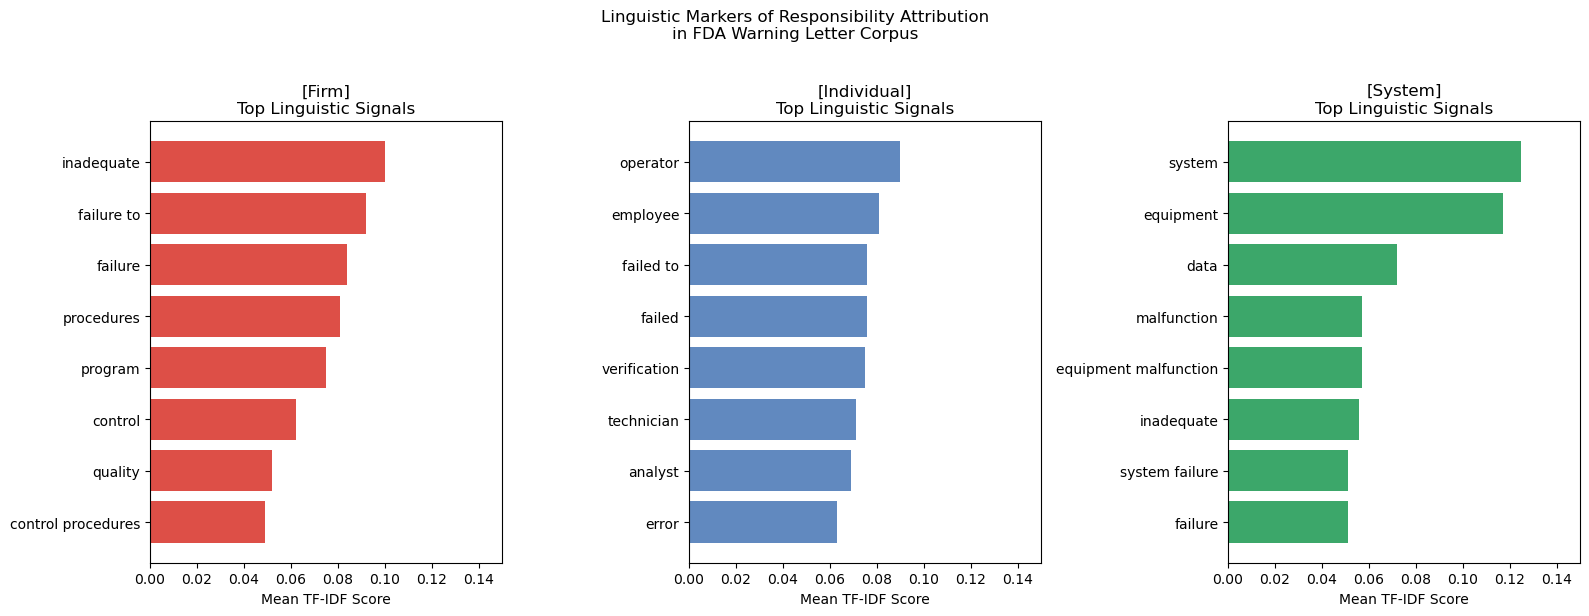

Saved!


In [9]:
# -------------------------------------------------------------
# Step 6: Visualize linguistic features — Figure 1
# -------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
colors = {'Firm': '#d73027', 'Individual': '#4575b4', 'System': '#1a9850'}

for ax, cls in zip(axes, classes):
    words = [w for w, _ in top_features[cls][:10]]
    scores = [s for _, s in top_features[cls][:10]]
    
    # Filter stopwords
    stopwords = {'to', 'of', 'in', 'the', 'and', 'for', 'by'}
    filtered = [(w, s) for w, s in zip(words, scores) if w not in stopwords][:8]
    words_f = [w for w, _ in filtered]
    scores_f = [s for _, s in filtered]
    
    ax.barh(words_f[::-1], scores_f[::-1], 
            color=colors[cls], alpha=0.85)
    ax.set_xlabel('Mean TF-IDF Score')
    ax.set_title(f'[{cls}]\nTop Linguistic Signals')
    ax.set_xlim(0, 0.15)

plt.suptitle('Linguistic Markers of Responsibility Attribution\nin FDA Warning Letter Corpus', 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures/attr1_linguistic_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [10]:
# -------------------------------------------------------------
# Save individual figures without titles
# -------------------------------------------------------------

for cls, color in colors.items():
    fig, ax = plt.subplots(figsize=(7, 5))
    
    words = [w for w, _ in top_features[cls][:12]]
    scores = [s for _, s in top_features[cls][:12]]
    stopwords = {'to', 'of', 'in', 'the', 'and', 'for', 'by'}
    filtered = [(w, s) for w, s in zip(words, scores) 
                if w not in stopwords][:8]
    words_f = [w for w, _ in filtered]
    scores_f = [s for _, s in filtered]
    
    ax.barh(words_f[::-1], scores_f[::-1], color=color, alpha=0.85)
    ax.set_xlabel('Mean TF-IDF Score')
    ax.set_xlim(0, 0.15)
    
    plt.tight_layout()
    plt.savefig(f'figures/attr1_{cls.lower()}_features.png', 
                dpi=150, bbox_inches='tight')
    plt.close()

print("Saved: attr1_firm_features.png")
print("Saved: attr1_individual_features.png")
print("Saved: attr1_system_features.png")

Saved: attr1_firm_features.png
Saved: attr1_individual_features.png
Saved: attr1_system_features.png


In [11]:
# -------------------------------------------------------------
# Step 7: Classification on annotated data
# Small dataset — use Leave-One-Out CV for robust evaluation
# -------------------------------------------------------------

from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import f1_score
import numpy as np

X_cls = tfidf_ann.transform(ann_df['text'])
y_cls = ann_df['label']

# Leave-One-Out CV (better for small datasets)
loo = LeaveOneOut()
models_cls = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True)
}

print("Leave-One-Out CV Results:")
print("-" * 45)

loo_results = {}
for name, model in models_cls.items():
    y_pred_all = []
    y_true_all = []
    
    for train_idx, test_idx in loo.split(X_cls):
        X_train_loo = X_cls[train_idx]
        X_test_loo = X_cls[test_idx]
        y_train_loo = y_cls.iloc[train_idx]
        y_test_loo = y_cls.iloc[test_idx]
        
        model.fit(X_train_loo, y_train_loo)
        y_pred = model.predict(X_test_loo)
        y_pred_all.extend(y_pred)
        y_true_all.extend(y_test_loo)
    
    f1 = f1_score(y_true_all, y_pred_all, average='macro')
    loo_results[name] = f1
    print(f"{name:25s}: F1 = {f1:.3f}")

Leave-One-Out CV Results:
---------------------------------------------
Logistic Regression      : F1 = 0.725
Random Forest            : F1 = 0.712
SVM                      : F1 = 0.556


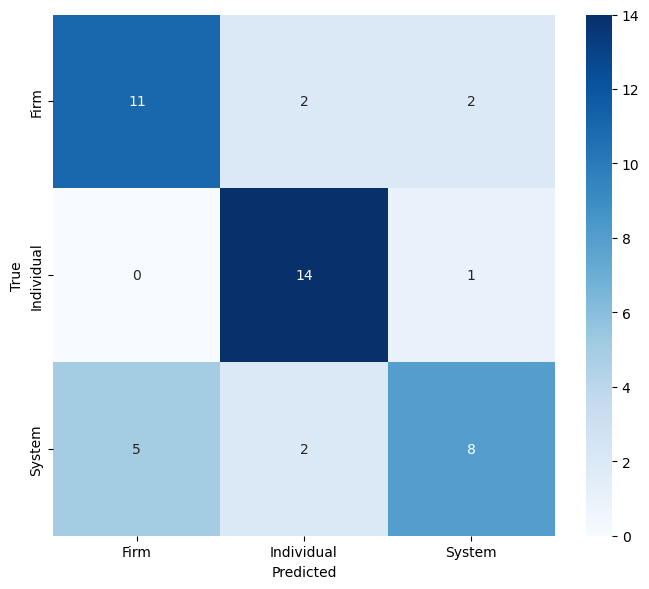


Classification Report:
              precision    recall  f1-score   support

        Firm       0.69      0.73      0.71        15
  Individual       0.78      0.93      0.85        15
      System       0.73      0.53      0.62        15

    accuracy                           0.73        45
   macro avg       0.73      0.73      0.72        45
weighted avg       0.73      0.73      0.72        45



In [12]:
# -------------------------------------------------------------
# Step 8: Confusion matrix analysis
# Where does the model confuse responsibility classes?
# -------------------------------------------------------------

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Use Logistic Regression (best performer)
best_model = LogisticRegression(random_state=42, max_iter=1000)
y_pred_all = []
y_true_all = []

for train_idx, test_idx in loo.split(X_cls):
    best_model.fit(X_cls[train_idx], y_cls.iloc[train_idx])
    y_pred = best_model.predict(X_cls[test_idx])
    y_pred_all.extend(y_pred)
    y_true_all.extend(y_cls.iloc[test_idx])

# Confusion matrix
cm = confusion_matrix(y_true_all, y_pred_all, 
                      labels=['Firm', 'Individual', 'System'])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Firm', 'Individual', 'System'],
            yticklabels=['Firm', 'Individual', 'System'],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('figures/attr2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_all,
      target_names=['Firm', 'Individual', 'System']))

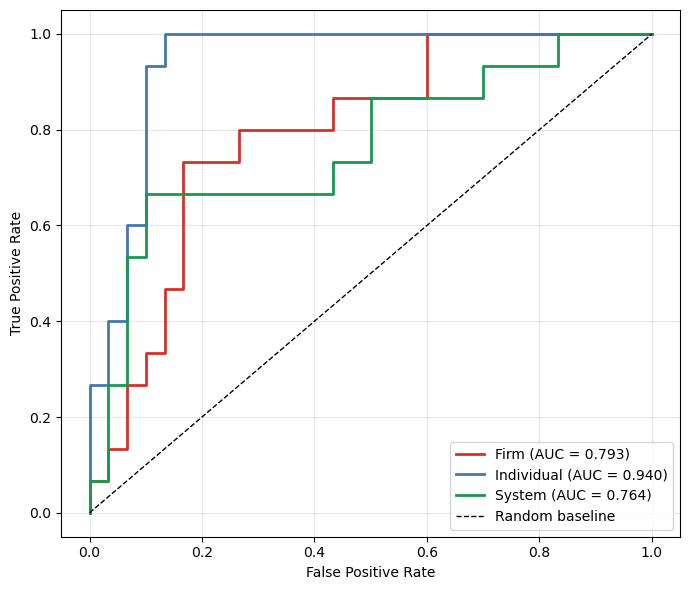

Saved!


In [13]:
# -------------------------------------------------------------
# Step 9: ROC curve — Figure 3
# -------------------------------------------------------------

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Get probabilities with LOO
best_model_prob = LogisticRegression(random_state=42, max_iter=1000)
y_prob_all = []
y_true_all = []

for train_idx, test_idx in loo.split(X_cls):
    best_model_prob.fit(X_cls[train_idx], y_cls.iloc[train_idx])
    y_prob = best_model_prob.predict_proba(X_cls[test_idx])
    y_prob_all.append(y_prob[0])
    y_true_all.extend(y_cls.iloc[test_idx])

y_prob_all = np.array(y_prob_all)
class_names = best_model_prob.classes_

# Binarize
lb = LabelBinarizer()
y_bin = lb.fit_transform(y_true_all)

fig, ax = plt.subplots(figsize=(7, 6))
colors_roc = ['#d73027', '#4575b4', '#1a9850']

for i, (cls, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_all[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/attr3_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [14]:
# -------------------------------------------------------------
# Step 10: Install LIME
# -------------------------------------------------------------

import subprocess
subprocess.run(['pip', 'install', 'lime', '--quiet'])
from lime.lime_text import LimeTextExplainer

print("LIME ready!")

LIME ready!


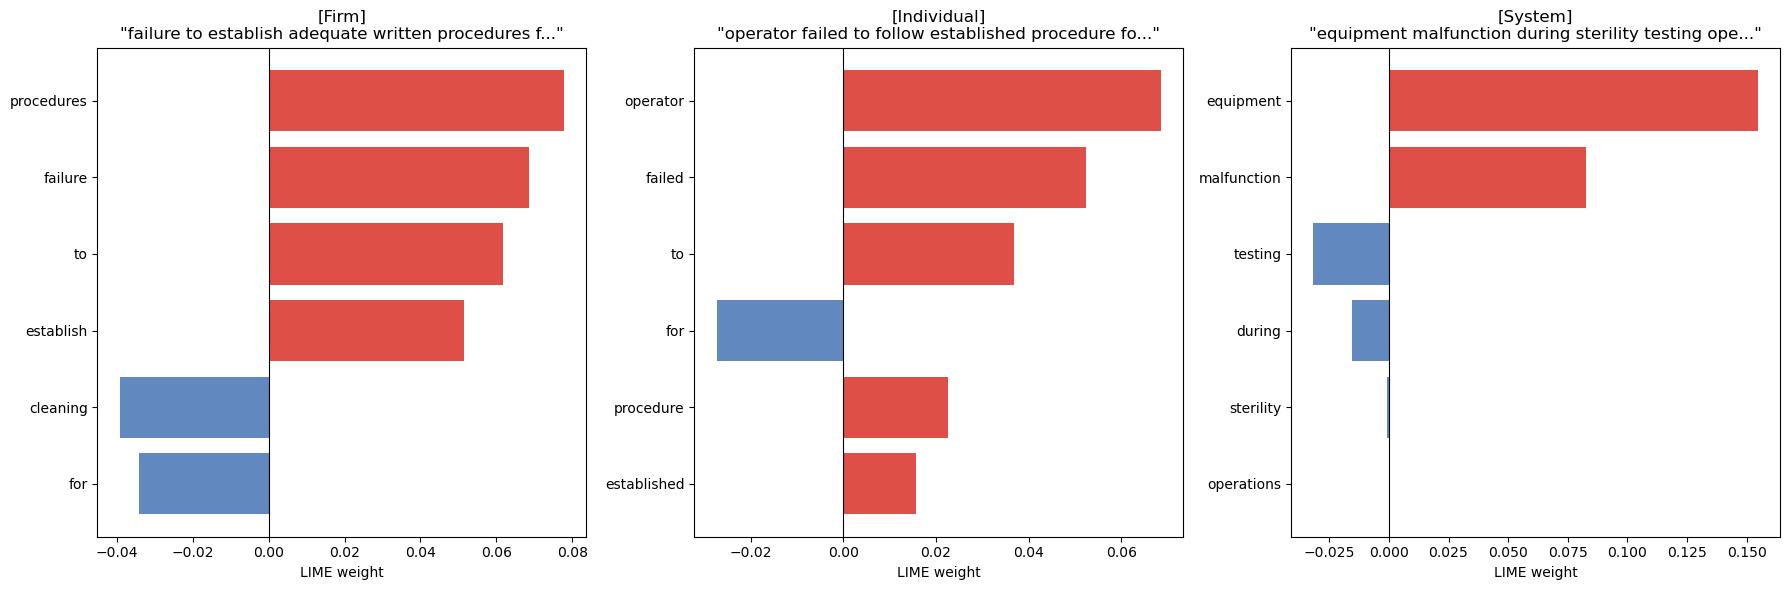

Saved!


In [15]:
# -------------------------------------------------------------
# Step 11: LIME explanation
# Why did the model make each prediction?
# -------------------------------------------------------------

# Train final model on all data
final_model = LogisticRegression(random_state=42, max_iter=1000)
final_model.fit(X_cls, y_cls)

# LIME explainer
explainer = LimeTextExplainer(class_names=['Firm', 'Individual', 'System'])

# Pipeline: text → TF-IDF → predict
def predict_proba_text(texts):
    X = tfidf_ann.transform(texts)
    return final_model.predict_proba(X)

# Explain 3 examples — one per class
examples = {
    'Firm': "failure to establish adequate written procedures for cleaning validation",
    'Individual': "operator failed to follow established procedure for batch release",
    'System': "equipment malfunction during sterility testing operations"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (true_label, text) in zip(axes, examples.items()):
    exp = explainer.explain_instance(
        text, predict_proba_text,
        num_features=6,
        labels=[0, 1, 2]  # Firm, Individual, System
    )
    
    # Get explanation for true class
    class_idx = list(final_model.classes_).index(true_label)
    exp_list = exp.as_list(label=class_idx)
    
    words = [e[0] for e in exp_list]
    weights = [e[1] for e in exp_list]
    colors_lime = ['#d73027' if w > 0 else '#4575b4' for w in weights]
    
    ax.barh(words[::-1], weights[::-1], color=colors_lime[::-1], alpha=0.85)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(f'[{true_label}]\n"{text[:50]}..."')
    ax.set_xlabel('LIME weight')

plt.tight_layout()
plt.savefig('figures/attr4_lime.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [16]:
# -------------------------------------------------------------
# Save LIME figures individually
# -------------------------------------------------------------

for true_label, text in examples.items():
    exp = explainer.explain_instance(
        text, predict_proba_text,
        num_features=6,
        labels=[0, 1, 2]
    )
    
    class_idx = list(final_model.classes_).index(true_label)
    exp_list = exp.as_list(label=class_idx)
    
    words = [e[0] for e in exp_list]
    weights = [e[1] for e in exp_list]
    colors_lime = ['#d73027' if w > 0 else '#4575b4' for w in weights]
    
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(words[::-1], weights[::-1], 
            color=colors_lime[::-1], alpha=0.85)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel('LIME weight')
    plt.tight_layout()
    plt.savefig(f'figures/attr4_lime_{true_label.lower()}.png', 
                dpi=150, bbox_inches='tight')
    plt.close()

print("Saved: attr4_lime_firm.png")
print("Saved: attr4_lime_individual.png")
print("Saved: attr4_lime_system.png")

Saved: attr4_lime_firm.png
Saved: attr4_lime_individual.png
Saved: attr4_lime_system.png


In [17]:
# -------------------------------------------------------------
# Step 12: Apply model to FDA Warning Letter corpus
# What does the model predict for real regulatory text?
# -------------------------------------------------------------

# Apply trained model to actual FDA violation texts
fda_texts = fda_df['ViolationText'].tolist()
X_fda = tfidf_ann.transform(fda_texts)
fda_pred = final_model.predict(X_fda)
fda_prob = final_model.predict_proba(X_fda)

fda_df['predicted_label'] = fda_pred
fda_df['confidence'] = fda_prob.max(axis=1)

print("Model predictions on FDA Warning Letter corpus:")
print(f"\nPredicted class distribution:")
print(pd.Series(fda_pred).value_counts())

print(f"\nActual vs Predicted:")
print(pd.crosstab(fda_df['ResponsibilitySubject'], 
                  fda_df['predicted_label'],
                  rownames=['Actual'], 
                  colnames=['Predicted']))

print(f"\nSample predictions:")
sample = fda_df[['ViolationText', 'ResponsibilitySubject', 
                  'predicted_label', 'confidence']].head(15)
print(sample.to_string(index=False))

Model predictions on FDA Warning Letter corpus:

Predicted class distribution:
Firm          108
System         49
Individual      3
Name: count, dtype: int64

Actual vs Predicted:
Predicted           Firm  Individual  System
Actual                                      
Firm                 108           3      48
QualityControlUnit     0           0       1

Sample predictions:
                                                  ViolationText ResponsibilitySubject predicted_label  confidence
                                environmental monitoring system                  Firm          System    0.512442
                                             written procedures                  Firm            Firm    0.519246
                                  laboratory records incomplete                  Firm      Individual    0.346667
                                 investigation of discrepancies                  Firm            Firm    0.430506
                                      OOS invest

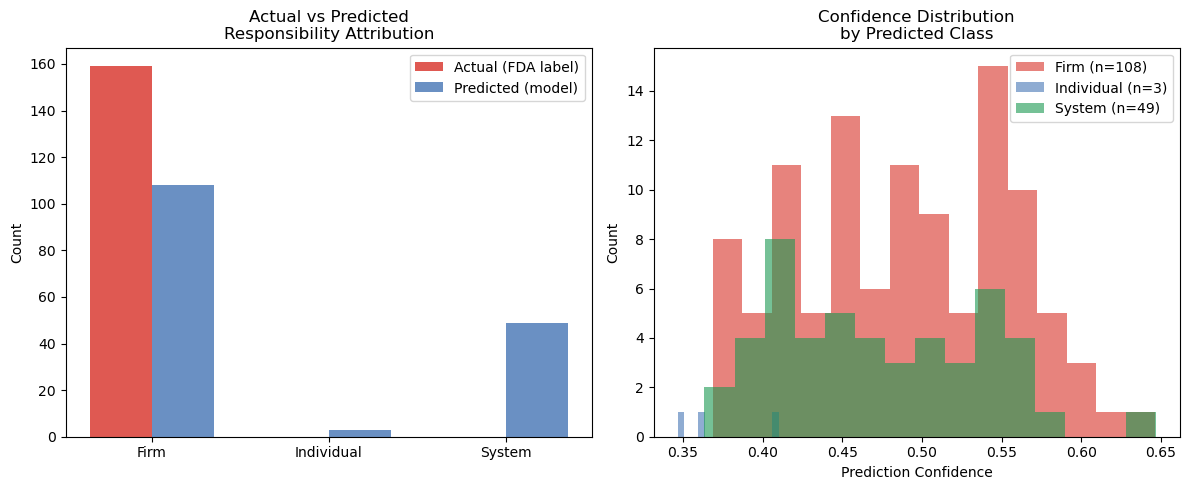

Saved!


In [18]:
# -------------------------------------------------------------
# Step 13: Visualize FDA corpus predictions — Figure 5
# -------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Figure 5a: Predicted vs Actual distribution
actual_counts = fda_df['ResponsibilitySubject'].value_counts()
predicted_counts = pd.Series(fda_pred).value_counts()

x = np.arange(3)
width = 0.35
labels = ['Firm', 'Individual', 'System']

actual_vals = [actual_counts.get('Firm', 0), 
               actual_counts.get('Individual', 0),
               actual_counts.get('System', 0)]
predicted_vals = [predicted_counts.get('Firm', 0),
                  predicted_counts.get('Individual', 0),
                  predicted_counts.get('System', 0)]

axes[0].bar(x - width/2, actual_vals, width, 
            label='Actual (FDA label)', color='#d73027', alpha=0.8)
axes[0].bar(x + width/2, predicted_vals, width,
            label='Predicted (model)', color='#4575b4', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Count')
axes[0].set_title('Actual vs Predicted\nResponsibility Attribution')
axes[0].legend()

# Figure 5b: Confidence distribution by predicted class
for cls, color in zip(['Firm', 'Individual', 'System'],
                      ['#d73027', '#4575b4', '#1a9850']):
    mask = fda_df['predicted_label'] == cls
    if mask.sum() > 0:
        axes[1].hist(fda_df[mask]['confidence'], bins=15,
                    alpha=0.6, color=color, label=f'{cls} (n={mask.sum()})')

axes[1].set_xlabel('Prediction Confidence')
axes[1].set_ylabel('Count')
axes[1].set_title('Confidence Distribution\nby Predicted Class')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/attr5_fda_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [19]:
# -------------------------------------------------------------
# Save Figure 5a and 5b individually
# -------------------------------------------------------------

# Figure 5a: Actual vs Predicted
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(3)
width = 0.35
labels = ['Firm', 'Individual', 'System']

ax.bar(x - width/2, actual_vals, width,
       label='Actual (FDA label)', color='#d73027', alpha=0.8)
ax.bar(x + width/2, predicted_vals, width,
       label='Predicted (model)', color='#4575b4', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('figures/attr5a_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.close()

# Figure 5b: Confidence distribution
fig, ax = plt.subplots(figsize=(7, 5))
for cls, color in zip(['Firm', 'Individual', 'System'],
                      ['#d73027', '#4575b4', '#1a9850']):
    mask = fda_df['predicted_label'] == cls
    if mask.sum() > 0:
        ax.hist(fda_df[mask]['confidence'], bins=15,
                alpha=0.6, color=color, label=f'{cls} (n={mask.sum()})')
ax.set_xlabel('Prediction Confidence')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('figures/attr5b_confidence.png', dpi=150, bbox_inches='tight')
plt.close()

print("Saved: attr5a_actual_vs_predicted.png")
print("Saved: attr5b_confidence.png")

Saved: attr5a_actual_vs_predicted.png
Saved: attr5b_confidence.png


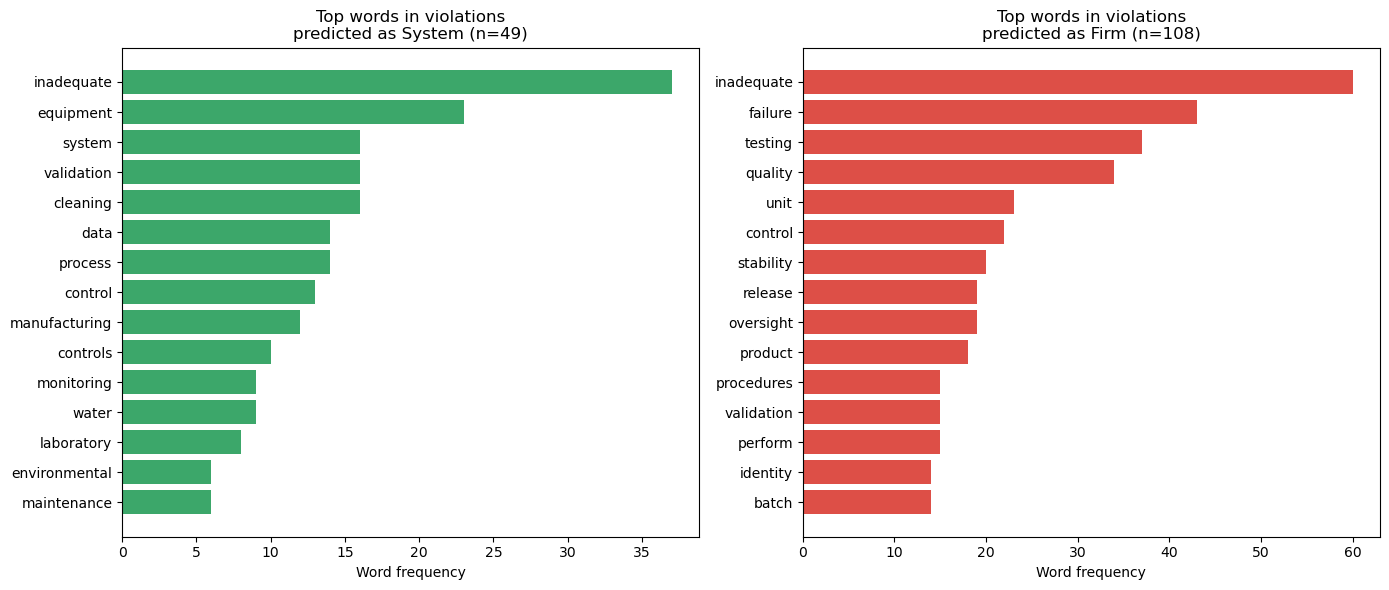

Saved!


In [20]:
# -------------------------------------------------------------
# Step 14: FDA corpus linguistic pattern analysis
# Which words appear in FDA text that model predicts as System?
# Key finding: FDA labels as Firm, model sees System language
# -------------------------------------------------------------

from collections import Counter
import re

def get_words(texts):
    words = []
    for text in texts:
        words.extend(re.findall(r'\b[a-z]+\b', text.lower()))
    return words

stopwords = {'to', 'of', 'in', 'the', 'and', 'for', 'by', 
             'a', 'an', 'or', 'is', 'are', 'was', 'were'}

# Words in FDA text predicted as System (but labeled Firm)
system_predicted = fda_df[fda_df['predicted_label'] == 'System']['ViolationText']
firm_predicted = fda_df[fda_df['predicted_label'] == 'Firm']['ViolationText']

system_words = [w for w in get_words(system_predicted) if w not in stopwords]
firm_words = [w for w in get_words(firm_predicted) if w not in stopwords]

system_counter = Counter(system_words).most_common(15)
firm_counter = Counter(firm_words).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# System-predicted words
words_s = [w for w, _ in system_counter]
counts_s = [c for _, c in system_counter]
axes[0].barh(words_s[::-1], counts_s[::-1], color='#1a9850', alpha=0.85)
axes[0].set_xlabel('Word frequency')
axes[0].set_title('Top words in violations\npredicted as System (n=49)')

# Firm-predicted words
words_f = [w for w, _ in firm_counter]
counts_f = [c for _, c in firm_counter]
axes[1].barh(words_f[::-1], counts_f[::-1], color='#d73027', alpha=0.85)
axes[1].set_xlabel('Word frequency')
axes[1].set_title('Top words in violations\npredicted as Firm (n=108)')

plt.tight_layout()
plt.savefig('figures/attr6_fda_linguistic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [21]:
# -------------------------------------------------------------
# Save Figure 6a and 6b individually
# -------------------------------------------------------------

# Figure 6a: System-predicted words
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(words_s[::-1], counts_s[::-1], color='#1a9850', alpha=0.85)
ax.set_xlabel('Word frequency')
plt.tight_layout()
plt.savefig('figures/attr6a_system_words.png', dpi=150, bbox_inches='tight')
plt.close()

# Figure 6b: Firm-predicted words
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(words_f[::-1], counts_f[::-1], color='#d73027', alpha=0.85)
ax.set_xlabel('Word frequency')
plt.tight_layout()
plt.savefig('figures/attr6b_firm_words.png', dpi=150, bbox_inches='tight')
plt.close()

print("Saved: attr6a_system_words.png")
print("Saved: attr6b_firm_words.png")

Saved: attr6a_system_words.png
Saved: attr6b_firm_words.png
